In [1]:
import pandas as pd
# --- Monta o Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Caminho do arquivo---
caminho = '/content/drive/MyDrive/Mestrado/tuPyE/tupye_dummy_vote.csv'

df = pd.read_csv(caminho)


Mounted at /content/drive


In [ ]:
#PRIMEIROS PASSOS OBSERVANDO O TUPYE
# --- Mostra as primeiras colunas para entender a estrutura ---
print("Colunas disponíveis:")
print(df.columns.tolist())
print("\nPrimeiras linhas:")
display(df.head())

# --- Filtra apenas as frases marcadas como capacitistas ---
if 'capacitism' in df.columns:
    frases_capacitistas = df[df['capacitism'] == 1]
    print(f"\nTotal de frases capacitistas: {len(frases_capacitistas)}\n")
    # Mostra algumas frases10))

# --- Exporta as frases capacitistas para CSV ---
if 'capacitism' in df.columns:
    frases_capacitistas = df[df['capacitism'] == 1]

    # Define o caminho onde o arquivo será salvo
    caminho_saida = '/content/drive/MyDrive/Mestrado/tuPyE/frases_capacitistas.csv'

    # Salva somente a coluna 'texto' (ajuste se quiser mais colunas)
    frases_capacitistas[['text']].to_csv(caminho_saida, index=False, encoding='utf-8')

    print(f"✅ CSV salvo em: {caminho_saida}")


Colunas disponíveis:
['id', 'text', 'aggressive', 'hate', 'ageism', 'aporophobia', 'body_shame', 'capacitism', 'lgbtphobia', 'political', 'racism', 'religious_intolerance', 'misogyny', 'xenophobia', 'other', 'researcher', 'year', 'source']

Primeiras linhas:


,id,text,aggressive,hate,ageism,aporophobia,body_shame,capacitism,lgbtphobia,political,racism,religious_intolerance,misogyny,xenophobia,other,researcher,year,source
0,1.65848623693028e+18,@user @user @user quanto vc pagava na época da...,1,1,0,0,0,1,0,1,0,0,0,0,0,oliveira et al,2023,twitter
1,1.65848623777333e+18,@user os árabes já vão lhes chutar do país ??,1,1,0,0,0,0,0,0,0,0,0,1,0,oliveira et al,2023,twitter
2,1.65848960585394e+18,@user @user @user @user @user tem que desenhar...,1,1,0,0,0,1,0,0,0,0,0,0,0,oliveira et al,2023,twitter
3,1.65849012716374e+18,@user @user chola mais gado. e se não quiser p...,1,1,0,0,0,0,0,1,0,0,0,0,0,oliveira et al,2023,twitter
4,1.65849018793945e+18,michele micheque nao tinha cartao do bolsonaro...,1,1,0,0,0,1,0,0,0,0,0,0,0,oliveira et al,2023,twitter



Total de frases capacitistas: 99

✅ CSV salvo em: /content/drive/MyDrive/Mestrado/tuPyE/frases_capacitistas.csv


In [ ]:
#PADRONIZANDO O TUPYE
import pandas as pd
import unicodedata
import re

# --- Monta o Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Caminho do arquivo ---
caminho = '/content/drive/MyDrive/Mestrado/tuPyE/tupye_dummy_vote.csv'

# --- Carrega o dataset ---
df = pd.read_csv(caminho)

# --- Função para padronizar texto ---
def padronizar_texto(texto):
    if pd.isna(texto):
        return ""
    # transforma em minúsculas
    texto = texto.lower()
    # remove acentuação
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # substitui hífen por espaço
    texto = texto.replace('-', ' ')
    # remove múltiplos espaços
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# --- Aplica a padronização ---
df["text_padronizado"] = df["text"].apply(padronizar_texto)

# --- Salva o novo arquivo ---
saida = '/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado.csv'
df.to_csv(saida, index=False)

print("✅ Padronização concluída! Arquivo salvo em:", saida)
print(df[["text", "text_padronizado"]].head(5))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Padronização concluída! Arquivo salvo em: /content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado.csv
                                                text  \
0  @user @user @user quanto vc pagava na época da...   
1      @user os árabes já vão lhes chutar do país ??   
2  @user @user @user @user @user tem que desenhar...   
3  @user @user chola mais gado. e se não quiser p...   
4  michele micheque nao tinha cartao do bolsonaro...   

                                    text_padronizado  
0  @user @user @user quanto vc pagava na epoca da...  
1      @user os arabes ja vao lhes chutar do pais ??  
2  @user @user @user @user @user tem que desenhar...  
3  @user @user chola mais gado. e se nao quiser p...  
4  michele micheque nao tinha cartao do bolsonaro...  


# Termos Capacitistas
O capacitismo se manifesta também na linguagem, por meio de palavras e expressões que reforçam estigmas, estereótipos e preconceitos contra pessoas com deficiência. Identificar e evitar esses termos é um passo importante para promover uma comunicação mais inclusiva e respeitosa.

Durante a pesquisa, encontrei um glossário em inglês de termos capacitistas elaborado por Autistic Hoya, disponível em:https://www.autistichoya.com/p/ableist-words-and-terms-to-avoid.html

https://www.ungeneva.org/sites/default/files/2021-01/Disability-Inclusive-Language-Guidelines.pdf

Em português, há também uma referência fundamental organizada por Romeu Kazumi Sassaki, intitulada Terminologia sobre deficiência na era da inclusão, disponível no portal do TSE: https://eadeje.tse.jus.br/pluginfile.php/177220/mod_resource/content/2/Romeu%20Kazumi%20Sassaki_Terminologia%20sobre%20defici%C3%AAncia%20na%20era%20da%20inclus%C3%A3o.pdf

https://www.defensoriapublica.pr.def.br/sites/default/arquivos_restritos/files/documento/2024-09/entendendo_o_capacitismo.pdf

Com base nessas fontes e em outras referências sobre linguagem inclusiva, foi elaborado o conjunto termos_capacitistas, que reúne palavras e expressões com conotação discriminatória relacionadas à deficiência — muitas delas ainda presentes no uso cotidiano, mas que devem ser substituídas por alternativas mais adequadas e respeitosas.



In [2]:
# Instala o spaCy
!pip install spacy --upgrade

# Baixa o modelo português grande
!python -m spacy download pt_core_news_lg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import spacy
from spacy.matcher import DependencyMatcher, Matcher
from collections import defaultdict, Counter
import pandas as pd
import csv

# --- Carrega modelo spaCy ---
nlp = spacy.load("pt_core_news_lg")


PROCESSO DE PROCURAR OS TERMOS CAPACITISTAS NO CORPUS TESTE 2

#PROCESSO DE PROCURAR OS TERMOS CAPACITISTAS NO CORPUS


TESTE 1

In [ ]:
#PROCESSO DE PROCURAR OS TERMOS CAPACITISTAS NO CORPUS TESTE 1

# --- Caminho dos arquivos ---
# caminho_arquivo = '/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado.csv'
# df = pd.read_csv(caminho_arquivo)
# df = df.dropna(subset=["text_padronizado"])  # garante que a coluna existe
# df["text_padronizado"] = df["text_padronizado"].astype(str)

# out_path = "/content/drive/MyDrive/Mestrado/tuPyE/achados_capacitismo2.csv"

# # --- Lista completa de termos capacitistas ---
# termos_capacitistas = [
#     # fisicos/mobilidade
#     "aleijado", "aleijada", "aleijados", "aleijadas",
#     "invalido", "invalida", "invalidos", "invalidas",
#     "defeituoso", "defeituosa", "defeituosos", "defeituosas",
#     "incapacitado", "incapacitada", "incapacitados", "incapacitadas",
#     "paralitico", "paralitica", "paraliticos", "paraliticas",
#     "tetraplegico", "tetraplegica", "tetraplegicos", "tetraplegicas",
#     "leproso", "leprosa", "leprosos", "leprosas", "lepra",

#     # auditiva/visual
#     "ceguinho", "ceguinha", "ceguinhos", "ceguinhas",
#     "surdinho", "surdinha", "surdinhos", "surdinhas",
#     "surdo mudo", "surda muda", "surdos mudos", "surdas mudas",
#     "cego mudo", "cega muda", "cegos mudos", "cegas mudas",

#     # intelectual/psicossocial
#     "retardado", "retardada", "retardados", "retardadas",
#     "lesado", "lesada", "lesados", "lesadas",
#     "retardo mental", "retardamento mental",
#     "mongoloide", "mongoloides", "mongol",
#     "demente", "dementes",
#     "idiota", "idiotas",
#     "imbecil", "imbecis",
#     "insano", "insana", "insanos", "insanas", "insanidade",
#     "lunatico", "lunatica", "lunaticos", "lunaticas",
#     "maniaco", "maniaca", "maniacos", "maniacas",
#     "psicopata", "psicopatas"
# ]

# # --- Lista de expressões multi-palavra (MWE) ---
# expressoes_mwe = [
#     # eufemismos / obsoletos
#     "portador de deficiencia", "portadores de deficiencia",
#     "portador de necessidades especiais", "portadores de necessidades especiais",
#     "pessoa especial", "pessoas especiais",
#     "diferentemente capaz", "diferentes capacidades", "habilidades diferenciadas",

#     # metáforas e expressões figuradas
#     "cego para", "parece que e cego", "fechar os olhos para","voce e cego", "voces sao cegos","cego para a realidade", "cego para os fatos", "cego de raiva", "cego de odio", "cegueira ideologica", "cegueira moral", "nao enxerga um palmo a frente", "andar as cegas"
#     "cego pela ignorancia", "cego pela intolerancia",
#     "surdo a criticas", "fazer ouvidos moucos", "se fazer de surdo","fazer de surdo",
#     "preso a cadeira de rodas", "confinado a cadeira de rodas",
#     "dar uma de joao sem braco", "deu mancada",
#     "fingir demencia","isso é coisa de doido", "só pode ser louco", "ficou maluco", "ideia maluca", "pirou de vez", "viajou na maionese", "nao bate bem da cabeca", "tem problema na cabeca", "fingir de louco", "dar uma de louco","uma de louco"
#     "esta mal das pernas", "sem pernas para isso",
#     "colocar o projeto de pe", "mal das pernas",
#     "igual a cego em tiroteio","cego em tiroteio",
#     "esta muito autista"
#     "isso é demencia", "so pode ter demencia", "ta com alzheimer?", "memoria de peixe",
#     "quebrado da cabeca", "retardo mental"
#   ]

# predicações copulares do tipo:
# [Sujeito] + ser/estar + [predicador capacitista]
# com/sem advérbio no meio (“muito”, “bastante”, etc.)
# com coordenação (“… é retardado e imbecil”, “…, idiota, insensível”)
# com aposto (“João, imbecil, …”)
# com termos predicativos NOM/ADJ (capacitistas como N ou ADJ)
# reconhecendo nomes próprios, pronomes e nomes comuns como sujeito



# dep = DependencyMatcher(nlp.vocab)
# matcher = Matcher(nlp.vocab)

# # Copulares: sujeito + ser/estar/parecer (+ adv) + termo capacitista
# pattern_cop = [
#     {"RIGHT_ID": "subj", "RIGHT_ATTRS": {"DEP": {"IN": ["nsubj","nsubj:pass"]},
#                                          "POS": {"IN": ["NOUN","PROPN","PRON"]}}},
#     {"LEFT_ID": "subj", "REL_OP": ">", "RIGHT_ID": "verb",
#      "RIGHT_ATTRS": {"LEMMA": {"IN": ["ser","estar","parecer"]}, "POS": {"IN": ["AUX","VERB"]}}},
#     {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "pred",
#      "RIGHT_ATTRS": {"POS": {"IN": ["ADJ","NOUN"]}, "LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# pattern_cop_adv = [
#     {"RIGHT_ID": "subj", "RIGHT_ATTRS": {"DEP": {"IN": ["nsubj","nsubj:pass"]},
#                                          "POS": {"IN": ["NOUN","PROPN","PRON"]}}},
#     {"LEFT_ID": "subj", "REL_OP": ">", "RIGHT_ID": "verb",
#      "RIGHT_ATTRS": {"LEMMA": {"IN": ["ser","estar","parecer"]}, "POS": {"IN": ["AUX","VERB"]}}},
#     {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "adv",
#      "RIGHT_ATTRS": {"DEP": "advmod", "POS": "ADV", "LOWER": {"IN": ["muito","bastante","bem","tão"]}}},
#     {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "pred",
#      "RIGHT_ATTRS": {"POS": {"IN": ["ADJ","NOUN"]}, "LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("COP_CAPACITISTA", [pattern_cop, pattern_cop_adv])

# # Caracterização genérica com verbos de ligação
# pattern_caracterizacao = [
#     {"RIGHT_ID": "verbo", "RIGHT_ATTRS": {"LEMMA": {"IN": verbos_ligacao}}},
#     {"LEFT_ID": "verbo", "REL_OP": ">", "RIGHT_ID": "sujeito",
#      "RIGHT_ATTRS": {"DEP": {"IN": ["nsubj","nsubj:pass"]}, "POS": {"IN": ["PROPN","NOUN","PRON"]}}},
#     {"LEFT_ID": "verbo", "REL_OP": ">", "RIGHT_ID": "termo",
#      "RIGHT_ATTRS": {"LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("CARACTERIZACAO", [pattern_caracterizacao])

# #Intensificação: verbo de ligação + advmod + termo
# pattern_intensificado = [
#     {"RIGHT_ID": "verbo", "RIGHT_ATTRS": {"LEMMA": {"IN": verbos_ligacao}}},
#     {"LEFT_ID": "verbo", "REL_OP": ">", "RIGHT_ID": "intens", "RIGHT_ATTRS": {"DEP": "advmod", "POS": "ADV"}},
#     {"LEFT_ID": "verbo", "REL_OP": ">", "RIGHT_ID": "termo",  "RIGHT_ATTRS": {"LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("INTENSIFICADO", [pattern_intensificado])

# # Comparação pejorativa: "como" + termo
# pattern_comparacao = [
#     {"RIGHT_ID": "verbo", "RIGHT_ATTRS": {"LEMMA": {"IN": ["parecer", "agir", "falar", "andar", "tratar"]}}},
#     {"LEFT_ID": "verbo", "REL_OP": ">", "RIGHT_ID": "comparador", "RIGHT_ATTRS": {"LOWER": "como"}},
#     {"LEFT_ID": "comparador", "REL_OP": ">", "RIGHT_ID": "termo", "RIGHT_ATTRS": {"LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("COMPARACAO_PEJORATIVA", [pattern_comparacao])

# #  Appos, amod e conj (adjetivo coordenado)
# pattern_appos = [
#     {"RIGHT_ID": "head", "RIGHT_ATTRS": {"POS": {"IN": ["PROPN", "NOUN"]}}},
#     {"LEFT_ID": "head", "REL_OP": ">", "RIGHT_ID": "app",
#      "RIGHT_ATTRS": {"DEP": "appos", "POS": {"IN": ["ADJ","NOUN"]}, "LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("APPOS_CAPACITISTA", [pattern_appos])

# pattern_amod = [
#     {"RIGHT_ID": "head", "RIGHT_ATTRS": {"POS": "NOUN", "LOWER": {"IN": list(nomes_pessoa_comuns)}}},
#     {"LEFT_ID": "head", "REL_OP": ">", "RIGHT_ID": "amod",
#      "RIGHT_ATTRS": {"DEP": "amod", "POS": "ADJ", "LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("AMOD_CAPACITISTA", [pattern_amod])

# pattern_conj_adj = [
#     {"RIGHT_ID": "adj1", "RIGHT_ATTRS": {"POS": "ADJ"}},
#     {"LEFT_ID": "adj1", "REL_OP": ">", "RIGHT_ID": "adj2",
#      "RIGHT_ATTRS": {"DEP": "conj", "POS": "ADJ", "LOWER": {"IN": list(termos_capacitistas)}}}
# ]
# dep.add("ADJ_CONJ_CAPACITISTA", [pattern_conj_adj])

# # Matcher
# matcher.add("DIRETO__VOCATIVO_POSSESSIVO",
#             [[{"LOWER": {"IN": ["seu","sua","teu","tua"]}}, {"LOWER": {"IN": list(termos_capacitistas)}}]])
# =========================
# DEPENDENCY MATCHER
# =========================


# # =========================================
# #  Funções de extração
# # =========================================
# def _sent_text_from_span(span):
#     """Retorna o texto da SENTENÇA completa que contém o span."""
#     try:
#         return span.sent.text
#     except Exception:
#         return span.text  # fallback: usa o próprio span se algo der errado

# def extrair_dep(doc):
#     resultados = []
#     for match_id, token_maps in dep(doc):
#         label = nlp.vocab.strings[match_id]

#         # normaliza para lista de mapeamentos
#         if isinstance(token_maps[0], int):
#             token_maps = [token_maps]

#         for tm in token_maps:
#             if isinstance(tm, dict):
#                 idx = tm
#             else:
#                 seq = list(tm)
#                 idx = {}
#                 # mapeamentos mínimos para spans (fallback para compatibilidade)
#                 if label in ("COP_CAPACITISTA", "CARACTERIZACAO") and len(seq) >= 3:
#                     idx = {"subj": seq[0], "verb": seq[1], "pred": seq[2]}
#                 elif label == "INTENSIFICADO" and len(seq) >= 3:
#                     idx = {"verbo": seq[0], "intens": seq[1], "termo": seq[2]}
#                 elif label == "COMPARACAO_PEJORATIVA" and len(seq) >= 3:
#                     idx = {"verbo": seq[0], "comparador": seq[1], "termo": seq[2]}
#                 elif label == "APPOS_CAPACITISTA" and len(seq) >= 2:
#                     idx = {"head": seq[0], "app": seq[1]}
#                 elif label == "AMOD_CAPACITISTA" and len(seq) >= 2:
#                     idx = {"head": seq[0], "amod": seq[1]}
#                 elif label == "ADJ_CONJ_CAPACITISTA" and len(seq) >= 2:
#                     idx = {"adj1": seq[0], "adj2": seq[1]}

#             # Spans por label (agora salvamos a SENTENÇA completa em 'sentenca')
#             if label in ("COP_CAPACITISTA", "CARACTERIZACAO") and all(k in idx for k in ("subj","pred")):
#                 subj, pred = doc[idx["subj"]], doc[idx["pred"]]
#                 span = doc[min(subj.i, pred.i):max(subj.i, pred.i)+1]
#                 resultados.append({
#                     "tipo": label,
#                     "termo": pred.text,
#                     "sujeito/cabeca": subj.text,
#                     "trecho": span.text,
#                     "sentenca": _sent_text_from_span(span)
#                 })

#             elif label == "INTENSIFICADO" and all(k in idx for k in ("verbo","termo")):
#                 v, t = doc[idx["verbo"]], doc[idx["termo"]]
#                 span = doc[min(v.i, t.i):max(v.i, t.i)+1]
#                 resultados.append({
#                     "tipo": label,
#                     "termo": t.text,
#                     "sujeito/cabeca": None,
#                     "trecho": span.text,
#                     "sentenca": _sent_text_from_span(span)
#                 })

#             elif label == "COMPARACAO_PEJORATIVA" and "termo" in idx:
#                 termo_tok = doc[idx["termo"]]
#                 # aqui a sentença é o doc inteiro; manteremos a consistência salvando a sentença do token
#                 resultados.append({
#                     "tipo": label,
#                     "termo": termo_tok.text,
#                     "sujeito/cabeca": None,
#                     "trecho": doc.text,
#                     "sentenca": _sent_text_from_span(termo_tok)
#                 })

#             elif label == "APPOS_CAPACITISTA" and all(k in idx for k in ("head","app")):
#                 head, pred = doc[idx["head"]], doc[idx["app"]]
#                 span = doc[min(head.i, pred.i):max(head.i, pred.i)+1]
#                 resultados.append({
#                     "tipo": label,
#                     "termo": pred.text,
#                     "sujeito/cabeca": head.text,
#                     "trecho": span.text,
#                     "sentenca": _sent_text_from_span(span)
#                 })

#             elif label == "AMOD_CAPACITISTA" and all(k in idx for k in ("head","amod")):
#                 head, pred = doc[idx["head"]], doc[idx["amod"]]
#                 span = doc[min(head.i, pred.i):max(head.i, pred.i)+1]
#                 resultados.append({
#                     "tipo": label,
#                     "termo": pred.text,
#                     "sujeito/cabeca": head.text,
#                     "trecho": span.text,
#                     "sentenca": _sent_text_from_span(span)
#                 })

#             elif label == "ADJ_CONJ_CAPACITISTA" and all(k in idx for k in ("adj1","adj2")):
#                 adj1, pred = doc[idx["adj1"]], doc[idx["adj2"]]
#                 span = doc[min(adj1.i, pred.i):max(adj1.i, pred.i)+1]
#                 resultados.append({
#                     "tipo": label,
#                     "termo": pred.text,
#                     "sujeito/cabeca": None,
#                     "trecho": span.text,
#                     "sentenca": _sent_text_from_span(span)
#                 })
#     return resultados

# def extrair_mwes(doc):
#     achados = []
#     for mid, start, end in matcher(doc):
#         label = nlp.vocab.strings[mid]
#         span = doc[start:end]
#         achados.append({
#             "tipo": label,
#             "termo": span.text,
#             "sujeito/cabeca": None,
#             "trecho": span.text,
#             "sentenca": _sent_text_from_span(span)  # <<< ALTERAÇÃO: salvar a sentença inteira
#         })
#     return achados

# # =========================================
# # Loop principal + registro com metadados
# # =========================================
# contagem_padroes = Counter()
# contagem_termos = Counter()
# registros = []

# # selecione as colunas do original que quer levar no CSV final
# cols_meta = [
#     "text", "text_padronizado",
#     "aggressive", "hate", "ageism", "aporophobia", "body_shame", "capacitism",
#     "lgbtphobia", "political", "racism", "religious_intolerance",
#     "misogyny", "xenophobia", "other",
#     "researcher", "year", "source"
# ]
# cols_meta = [c for c in cols_meta if c in df.columns]

# def pegar_meta(row, colnames):
#     return {c: row[c] if c in row else None for c in colnames}

# for idx, row in df.iterrows():
#     texto_norm = row["text_padronizado"].strip().lower()
#     doc = nlp(texto_norm)
#     meta = pegar_meta(row, cols_meta)
#     meta["_row_index"] = idx  # referência da linha no CSV original

#     # DependencyMatcher
#     for h in extrair_dep(doc):
#         contagem_padroes[h["tipo"]] += 1
#         contagem_termos[h["termo"]] += 1
#         registro = {
#             "padrao_grupo": "SINTATICO",
#             "match_tipo": h["tipo"],
#             "match_termo": h["termo"],
#             "match_sujeito": h.get("sujeito/cabeca"),
#             "match_trecho": h["sentenca"]
#         }
#         registro.update(meta)
#         registros.append(registro)

#     # Matcher (MWE/superfície)
#     for h in extrair_mwes(doc):
#         contagem_padroes[h["tipo"]] += 1
#         contagem_termos[h["termo"]] += 1
#         registro = {
#             "padrao_grupo": "MWE",
#             "match_tipo": h["tipo"],
#             "match_termo": h["termo"],
#             "match_sujeito": h.get("sujeito/cabeca"),
#             "match_trecho": h["sentenca"]
#         }
#         registro.update(meta)
#         registros.append(registro)

# # =========================================
# # Relatórios e salvamento
# # =========================================
# print("\n=== CONTAGEM DE PADRÕES DETECTADOS ===")
# for tipo, qtd in contagem_padroes.items():
#     print(f"{tipo}: {qtd}")

# print("\n=== TOP 20 TERMOS CAPACITISTAS DETECTADOS ===")
# for termo, qtd in contagem_termos.most_common(20):
#     print(f"{termo}: {qtd}")

# df_hits = pd.DataFrame(registros)

# # organiza colunas: primeiro info de match, depois metadados
# cols_match = ["padrao_grupo", "match_tipo", "match_termo", "match_sujeito", "match_trecho"]
# cols_final = cols_match + [c for c in cols_meta if c not in cols_match] + ["_row_index"]
# df_hits = df_hits.reindex(columns=cols_final)

# df_hits.to_csv(out_path, index=False, encoding="utf-8")
# print(f"\n[OK] Arquivo salvo em: {out_path}")


=== CONTAGEM DE PADRÕES DETECTADOS ===
SURF__NOUN_PROPN_PRON_PERTO_CAP: 763
CARACTERIZACAO: 110
MWE__CEGO_DE_ODIO: 1
ADJ_CONJ_CAPACITISTA: 10
MWE__FECHAR_OS_OLHOS_PARA: 1
INTENSIFICADO: 37
DIRETO__VOCATIVO_POSSESSIVO: 9
MWE__PIROU_DE_VEZ: 1
MWE__NAO_BATE_BEM_DA_CABECA: 1
MWE__IDEIA_MALUCA: 1
APPOS_CAPACITISTA: 2

=== TOP 20 TERMOS CAPACITISTAS DETECTADOS ===
idiota: 54
imbecil: 33
idiotas: 15
retardada: 12
demente: 9
retardado: 9
mongoloide: 6
gente idiota: 5
bolsonaro, como o imbecil: 5
pergunta idiota: 5
eu sou idiota: 5
imbecis: 4
seu idiota: 4
insana: 3
mulher imbecil: 3
eu sou mt idiota: 3
voce e um idiota: 3
gente retardada: 3
cara de idiota: 3
mongol: 3

[OK] Arquivo salvo em: /content/drive/MyDrive/Mestrado/tuPyE/achados_capacitismo2.csv


 TESTE 2 - CONCRETO

In [4]:
# ============================================================
# PROCESSO DE PROCURAR CAPACITISMO NO CORPUS (TESTE 2)
# ============================================================

import pandas as pd
from collections import Counter
import spacy
from spacy.matcher import Matcher, DependencyMatcher

# -------------------------
# Carregar modelo spaCy PT
# -------------------------
try:
    nlp
except NameError:
    try:
        nlp = spacy.load("pt_core_news_lg")
    except Exception:
        nlp = spacy.load("pt_core_news_sm")

# -------------------------
# Caminho dos arquivos
# -------------------------
caminho_arquivo = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado.csv"
df = pd.read_csv(caminho_arquivo)
df = df.dropna(subset=["text_padronizado"])
df["text_padronizado"] = df["text_padronizado"].astype(str)

out_path = "/content/drive/MyDrive/Mestrado/tuPyE/achados_capacitismo2.csv"


# -------------------------
termos_capacitistas = [
    # físicos / mobilidade
    "aleijado", "aleijada", "aleijados", "aleijadas",
    "invalido", "invalida", "invalidos", "invalidas",
    "defeituoso", "defeituosa", "defeituosos", "defeituosas",
    "deficiente", "deficientes", "deficincia",  # (mantive como você escreveu)
    "incapacitado", "incapacitada", "incapacitados", "incapacitadas",
    "paralitico", "paralitica", "paraliticos", "paraliticas",
    "tetraplegico", "tetraplegica", "tetraplegicos", "tetraplegicas",
    "leproso", "leprosa", "leprosos", "leprosas", "lepra",
    "muleta", "manco", "mancada",

    # auditiva/visual
    "cego", "ceguinho", "ceguinha", "ceguinhos", "ceguinhas", "cegueira",
    "surdo", "surdinho", "surdinha", "surdinhos", "surdinhas",

    # multi-token (não entram no CAP_SET, mas mantidos por completude)
    "surdo mudo", "surda muda", "surdos mudos", "surdas mudas",
    "cego mudo", "cega muda", "cegos mudos", "cegas mudas",

    # intelectual/psicossocial
    "retardado", "retardada", "retardados", "retardadas",
    "lesado", "lesada", "lesados", "lesadas",
    "retardo mental", "retardamento mental",  # multi-token
    "mongoloide", "mongoloides", "mongol",
    "demente", "dementes",
    "idiota", "idiotas",
    "imbecil", "imbecis",
    "insano", "insana", "insanos", "insanas", "insanidade",
    "lunatico", "lunatica", "lunaticos", "lunaticas",
    "maniaco", "maniaca", "maniacos", "maniacas",
    "psicopata", "psicopatas",
]

# -------------------------
# Expressões MWEs
# -------------------------
expressoes_mwe = [
    # eufemismos / obsoletos
    "portador de deficiencia",
    "portadores de deficiencia",
    "possui deficincia",
    "tem deficincia",
    "portador de necessidades especiais",
    "portadores de necessidades especiais",
    "pessoa especial",
    "pessoas especiais",
    "diferentemente capaz",
    "diferentes capacidades",
    "habilidades diferenciadas",
    "pessoa normal",
    "pessoas normais",
    "pessoa com deficiencia",
    "pessoas com deficiencia",
    "pessoas com deficiencias",
    "pessoa com necessidades especiais",
    "pessoas com necessidades especiais",

    # MWEs capacitistas multi-token (também úteis)
    "surdo mudo", "surda muda", "surdos mudos", "surdas mudas",
    "cego mudo", "cega muda", "cegos mudos", "cegas mudas",
    "retardo mental",
    "retardamento mental",

    # metáforas / expressões figuradas
    "cego para a realidade",
    "cego para os fatos",
    "cego de raiva",
    "cego de odio",
    "cegueira ideologica",
    "cegueira moral",
    "nao enxerga um palmo a frente",
    "nao ve um palmo a frente",
    "andar as cegas",
    "anda as cegas",
    "cego pela ignorancia",
    "cego pela intolerancia",
    "surdo a criticas",
    "fazer ouvidos moucos",
    "se fazer de surdo",
    "fazer de surdo",
    "preso a cadeira de rodas",
    "confinado a cadeira de rodas",
    "cadeira de rodas",
    "desculpa de manco e muleta",
    "dar uma de joao sem braco",
    "deu mancada",
    "que mancada",
    "fingir demencia",
    "isso e coisa de doido",
    "so pode ser louco",
    "ficou maluco",
    "ideia maluca",
    "pirou de vez",
    "nao bate bem da cabeca",
    "tem problema na cabeca",
    "fingir de louco",
    "dar uma de louco",
    "uma de louco",
    "esta mal das pernas",
    "sem pernas para isso",
    "igual a cego em tiroteio",
    "cego em tiroteio",
    "esta muito autista",
    "muito autista",
    "isso e demencia",
    "so pode ter demencia",
    "tem demencia",
    "ta com alzheimer",
    "memoria de peixe",
    "quebrado da cabeca",
    "sem nocao",
    "em terra de cego quem tem olho e rei",
]

# ============================================================
# SETS / HELPERS
# ============================================================

CAP_SET = set([t.strip().lower() for t in termos_capacitistas if " " not in t.strip()])

def _overlaps(a_start, a_end, b_start, b_end):
    return (a_start < b_end) and (b_start < a_end)

def _sent_text(span):
    try:
        return span.sent.text
    except Exception:
        return span.text

def _cap_toks_in_span(span):
    """Retorna lista de tokens (spacy.Token) cujo lower_ está em CAP_SET."""
    return [t for t in span if t.lower_ in CAP_SET]

def _cap_ix_in_span(span):
    return {t.i for t in span if t.lower_ in CAP_SET}

def _priority(label: str) -> int:
    # Maior = mais importante
    if label.startswith("MWE__"):
        return 4
    if label == "MWE_DIRETO_VOCATIVO_POSSESSIVO":
        return 3
    if label == "MWE_INDIRETO":
        return 2
    if label == "MWE_DIRETO":
        return 1
    return 0

def _span_from_token_ids(doc, token_ids):
    toks = [doc[i] for i in token_ids]
    start = min(t.i for t in toks)
    end = max(t.i for t in toks) + 1
    return doc[start:end]

# ============================================================
# MATCHERS
# ============================================================
dep = DependencyMatcher(nlp.vocab)
matcher = Matcher(nlp.vocab)

# ============================================================
# PADRÕES SINTÁTICOS
# ============================================================
TERM_ATTRS = {"LOWER": {"IN": list(CAP_SET)}}
SUBJ_ATTRS = {"DEP": {"IN": ["nsubj", "nsubj:pass"]}, "POS": {"IN": ["NOUN", "PROPN", "PRON"]}}

# 1) termo(cap) -> head -> subj
pattern_gen_pred_subj = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX", "NOUN", "ADJ"]}}},
    {"LEFT_ID": "head", "REL_OP": ">", "RIGHT_ID": "subj",
     "RIGHT_ATTRS": {**SUBJ_ATTRS}},
]
dep.add("GEN_PRED_SUBJ", [pattern_gen_pred_subj])

# 2) termo(cap) -> head -> subj + advmod no termo
pattern_gen_pred_subj_adv = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX", "NOUN", "ADJ"]}}},
    {"LEFT_ID": "head", "REL_OP": ">", "RIGHT_ID": "subj",
     "RIGHT_ATTRS": {**SUBJ_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": ">", "RIGHT_ID": "adv",
     "RIGHT_ATTRS": {"DEP": "advmod", "POS": "ADV"}},
]
dep.add("GEN_PRED_SUBJ_ADV", [pattern_gen_pred_subj_adv])

# 3) aposto: "Mariana, idiota"
pattern_gen_appos = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"DEP": "appos", "POS": {"IN": ["NOUN", "PROPN", "PRON"]}}},
]
dep.add("GEN_APPOS", [pattern_gen_appos])

# 4) amod: "menina idiota" (term como ADJ amod de NOUN/PROPN/PRON)
pattern_gen_amod = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "amod",
     "RIGHT_ATTRS": {"DEP": "amod", "POS": "ADJ"}},
    {"LEFT_ID": "amod", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"POS": {"IN": ["NOUN", "PROPN", "PRON"]}}},
]
dep.add("GEN_AMOD", [pattern_gen_amod])

# 5) conj: "burra e idiota"
pattern_gen_conj = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"DEP": "conj", "POS": {"IN": ["ADJ", "NOUN"]}}},
]
dep.add("GEN_CONJ", [pattern_gen_conj])

# 6) oprd/xcomp: "acho ela idiota", "considero ele imbecil"
pattern_gen_oprd_xcomp = [
    {"RIGHT_ID": "term", "RIGHT_ATTRS": {**TERM_ATTRS}},
    {"LEFT_ID": "term", "REL_OP": "<", "RIGHT_ID": "head",
     "RIGHT_ATTRS": {"DEP": {"IN": ["oprd", "xcomp"]}, "POS": {"IN": ["VERB", "AUX"]}}},
]
dep.add("GEN_OPRD_XCOMP", [pattern_gen_oprd_xcomp])

# 7) ADJ_CONJ (seu pedido)
pattern_conj_adj = [
    {"RIGHT_ID": "adj1", "RIGHT_ATTRS": {"POS": "ADJ"}},
    {"LEFT_ID": "adj1", "REL_OP": ">", "RIGHT_ID": "term",
     "RIGHT_ATTRS": {"DEP": "conj", "POS": "ADJ", **TERM_ATTRS}},
]
dep.add("ADJ_CONJ_CAP", [pattern_conj_adj])

# ============================================================
# MATCHER DE SUPERFÍCIE (MWE e afins)
#    3) heurísticos na ordem:
#         MWE_DIRETO_VOCATIVO_POSSESSIVO -> MWE_INDIRETO -> MWE_DIRETO
# ============================================================

# 1) MWEs da lista (MWE__*)
def add_mwe_pattern(name: str, phrase: str):
    toks = phrase.split()
    pattern = [{"LOWER": tok} for tok in toks]
    matcher.add(name, [pattern])

for exp in sorted(set(expressoes_mwe)):
    name = "MWE__" + exp.replace(" ", "_").upper()
    add_mwe_pattern(name, exp)

# 2) vocativo possessivo
matcher.add(
    "MWE_DIRETO_VOCATIVO_POSSESSIVO",
    [[
        {"LOWER": {"IN": ["seu", "sua", "teu", "tua"]}},
        {"LOWER": {"IN": list(CAP_SET)}},
    ]],
)

# 3) indireto (pessoa + janela + termo)
matcher.add(
    "MWE_INDIRETO",
    [[
        {"POS": {"IN": ["NOUN", "PROPN", "PRON"]}},
        {"POS": {"IN": ["DET", "ADJ", "ADV", "PUNCT"]}, "OP": "{0,6}"},
        {"LOWER": {"IN": list(CAP_SET)}},
    ]],
)

# 4) token sozinho
matcher.add(
    "MWE_DIRETO",
    [[{"LOWER": {"IN": list(CAP_SET)}}]],
)

# ============================================================
# EXTRAÇÃO COM BLOQUEIO POR TOKEN
# ============================================================

def extrair_mwe_por_filtro(doc, blocked_cap_token_ix, label_filter_fn):
    """
    Extrai matches do Matcher, filtrando por label (label_filter_fn(label)->bool).
    Emite 1 registro POR TERMO (token) no span, quando houver tokens simples (CAP_SET).
    Para MWEs sem tokens simples (metáforas), emite 1 registro pelo span inteiro.
    Também evita overlap entre MWEs aceitos nesta chamada (used_spans).
    Atualiza blocked_cap_token_ix por token.
    """
    candidatos = []

    for mid, start, end in matcher(doc):
        label = nlp.vocab.strings[mid]
        if not label_filter_fn(label):
            continue

        span = doc[start:end]
        cap_toks = _cap_toks_in_span(span)
        cap_ix = {t.i for t in cap_toks}

        # se tem tokens simples e algum já bloqueado, ignora
        if cap_ix and (cap_ix & blocked_cap_token_ix):
            continue

        candidatos.append({
            "tipo": label,
            "span": span,
            "_tok_start": start,
            "_tok_end": end,
            "_prio": _priority(label),
            "_len": (end - start),
            "_cap_toks": cap_toks,
        })

    # ordena para escolher os mais “fortes” primeiro
    candidatos.sort(key=lambda x: (-x["_prio"], -x["_len"]))

    escolhidos = []
    used_spans = []

    for c in candidatos:
        start, end = c["_tok_start"], c["_tok_end"]
        if any(_overlaps(start, end, a0, a1) for (a0, a1) in used_spans):
            continue

        span = c["span"]
        label = c["tipo"]
        cap_toks = c["_cap_toks"]

        # Caso 1: tem tokens simples -> 1 registro por token (não duplicar token)
        if cap_toks:
            for t in cap_toks:
                if t.i in blocked_cap_token_ix:
                    continue
                blocked_cap_token_ix.add(t.i)
                escolhidos.append({
                    "tipo": label,
                    "termo": t.text,
                    "sujeito/cabeca": None,
                    "trecho": span.text,
                    "sentenca": _sent_text(span),
                    "_tok_start": start,
                    "_tok_end": end,
                })
            used_spans.append((start, end))
            continue

        # Caso 2: sem tokens simples -> metáfora/expressão (conta 1 pelo span)
        escolhidos.append({
            "tipo": label,
            "termo": span.text,
            "sujeito/cabeca": None,
            "trecho": span.text,
            "sentenca": _sent_text(span),
            "_tok_start": start,
            "_tok_end": end,
        })
        used_spans.append((start, end))

    return escolhidos, blocked_cap_token_ix


def extrair_dep(doc, blocked_cap_token_ix):
    """
    Extrai padrões sintáticos:
    - Cria 1 registro por TERMO (token) em CAP_SET dentro do span do match.
    - Não duplica token já bloqueado.
    - Retorna spans aceitos (para evitar overlap posterior, se quiser usar).
    """
    resultados = []
    spans_aceitos = []

    for match_id, token_ids in dep(doc):
        label = nlp.vocab.strings[match_id]
        if not token_ids:
            continue

        span = _span_from_token_ids(doc, token_ids)
        cap_toks = _cap_toks_in_span(span)

        # se não tem nenhum termo simples, não é útil pra nossa contagem por token
        if not cap_toks:
            continue

        # se todos já bloqueados, pula
        if all(t.i in blocked_cap_token_ix for t in cap_toks):
            continue

        # registra 1 por token e bloqueia cada token
        any_added = False
        for t in cap_toks:
            if t.i in blocked_cap_token_ix:
                continue
            blocked_cap_token_ix.add(t.i)
            resultados.append({
                "tipo": label,
                "termo": t.text,
                "sujeito/cabeca": None,
                "trecho": span.text,
                "sentenca": _sent_text(span),
                "_tok_start": span.start,
                "_tok_end": span.end,
            })
            any_added = True

        if any_added:
            spans_aceitos.append((span.start, span.end))

    return resultados, spans_aceitos, blocked_cap_token_ix


# ============================================================
# LOOP PRINCIPAL + CSV
# ============================================================
contagem_padroes = Counter()
contagem_termos = Counter()
registros = []

cols_meta = [
    "text", "text_padronizado",
    "aggressive", "hate", "ageism", "aporophobia", "body_shame", "capacitism",
    "lgbtphobia", "political", "racism", "religious_intolerance",
    "misogyny", "xenophobia", "other",
    "researcher", "year", "source",
]
cols_meta = [c for c in cols_meta if c in df.columns]

def pegar_meta(row, colnames):
    return {c: row[c] if c in row else None for c in colnames}

for idx, row in df.iterrows():
    texto_norm = row["text_padronizado"].strip().lower()
    if not texto_norm:
        continue

    doc = nlp(texto_norm)

    meta = pegar_meta(row, cols_meta)
    meta["_row_index"] = idx

    # bloqueio por doc (por token)
    blocked_cap_token_ix = set()

    # --------------------------------------------------------
    # 1) PRIMEIRO: expressoes_mwe (labels MWE__*)
    # --------------------------------------------------------
    hits_mwe_lista, blocked_cap_token_ix = extrair_mwe_por_filtro(
        doc,
        blocked_cap_token_ix,
        label_filter_fn=lambda lab: lab.startswith("MWE__"),
    )
    for h in hits_mwe_lista:
        contagem_padroes[h["tipo"]] += 1
        contagem_termos[h["termo"]] += 1

        registro = {
            "padrao_grupo": "MWE_LISTA",
            "match_tipo": h["tipo"],
            "match_termo": h["termo"],
            "match_sujeito": h.get("sujeito/cabeca"),
            "match_trecho": h["sentenca"],
            "_tok_start": h.get("_tok_start"),
            "_tok_end": h.get("_tok_end"),
        }
        registro.update(meta)
        registros.append(registro)

    # --------------------------------------------------------
    # 2) SEGUNDO: PADRÕES SINTÁTICOS
    # --------------------------------------------------------
    hits_dep, spans_sintaticos, blocked_cap_token_ix = extrair_dep(doc, blocked_cap_token_ix)
    for h in hits_dep:
        contagem_padroes[h["tipo"]] += 1
        contagem_termos[h["termo"]] += 1

        registro = {
            "padrao_grupo": "SINTATICO",
            "match_tipo": h["tipo"],
            "match_termo": h["termo"],
            "match_sujeito": h.get("sujeito/cabeca"),
            "match_trecho": h["sentenca"],
            "_tok_start": h.get("_tok_start"),
            "_tok_end": h.get("_tok_end"),
        }
        registro.update(meta)
        registros.append(registro)

    # --------------------------------------------------------
    # 3) TERCEIRO: MWEs heurísticas na ordem
    #    - MWE_DIRETO_VOCATIVO_POSSESSIVO
    #    - MWE_INDIRETO
    #    - MWE_DIRETO -- oq sobrou entra
    # --------------------------------------------------------
    ordem_heur = ["MWE_DIRETO_VOCATIVO_POSSESSIVO", "MWE_INDIRETO", "MWE_DIRETO"]
    for lab_alvo in ordem_heur:
        hits_heur, blocked_cap_token_ix = extrair_mwe_por_filtro(
            doc,
            blocked_cap_token_ix,
            label_filter_fn=lambda lab, alvo=lab_alvo: lab == alvo,
        )
        for h in hits_heur:
            contagem_padroes[h["tipo"]] += 1
            contagem_termos[h["termo"]] += 1

            registro = {
                "padrao_grupo": "MWE_HEUR",
                "match_tipo": h["tipo"],
                "match_termo": h["termo"],
                "match_sujeito": h.get("sujeito/cabeca"),
                "match_trecho": h["sentenca"],
                "_tok_start": h.get("_tok_start"),
                "_tok_end": h.get("_tok_end"),
            }
            registro.update(meta)
            registros.append(registro)

# ============================================================
# RELATÓRIOS E SALVAMENTO
# ============================================================
print("\n=== CONTAGEM DE PADRÕES DETECTADOS ===")
for tipo, qtd in contagem_padroes.items():
    print(f"{tipo}: {qtd}")

print("\n=== TOP 30 TERMOS/EXPRESSÕES DETECTADOS ===")
for termo, qtd in contagem_termos.most_common(30):
    print(f"{termo}: {qtd}")

df_hits = pd.DataFrame(registros)

cols_match = [
    "padrao_grupo",
    "match_tipo",
    "match_termo",
    "match_sujeito",
    "match_trecho",
    "_tok_start",
    "_tok_end",
]
cols_final = cols_match + [c for c in cols_meta if c not in cols_match] + ["_row_index"]
df_hits = df_hits.reindex(columns=cols_final)

df_hits.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n[OK] Arquivo salvo em: {out_path}")

#total 782


=== CONTAGEM DE PADRÕES DETECTADOS ===
MWE_DIRETO: 344
GEN_PRED_SUBJ: 121
MWE_INDIRETO: 159
GEN_CONJ: 31
MWE__SEM_NOCAO: 55
GEN_APPOS: 9
MWE__CEGO_DE_ODIO: 1
MWE__PESSOAS_NORMAIS: 6
MWE__PESSOA_NORMAL: 3
ADJ_CONJ_CAP: 4
GEN_OPRD_XCOMP: 31
GEN_AMOD: 7
MWE__PESSOAS_COM_DEFICIENCIA: 1
MWE_DIRETO_VOCATIVO_POSSESSIVO: 5
MWE__PIROU_DE_VEZ: 1
MWE__NAO_BATE_BEM_DA_CABECA: 1
MWE__IDEIA_MALUCA: 1
MWE__CADEIRA_DE_RODAS: 1

=== TOP 30 TERMOS/EXPRESSÕES DETECTADOS ===
idiota: 294
imbecil: 87
retardado: 74
retardada: 62
sem nocao: 55
idiotas: 46
cego: 19
psicopata: 19
imbecis: 14
demente: 14
mongol: 14
mongoloide: 12
pessoas normais: 6
insana: 6
retardados: 6
insanos: 4
surdo: 4
insano: 4
insanidade: 4
pessoa normal: 3
mancada: 3
lunatico: 3
dementes: 3
deficiente: 2
cegueira: 2
psicopatas: 2
lesado: 2
lesada: 1
lunaticas: 1
incapacitado: 1

[OK] Arquivo salvo em: /content/drive/MyDrive/Mestrado/tuPyE/achados_capacitismo2.csv


In [14]:
#JUNTAR NOVAMENTE OS ACHADOS DO CAPTA-PTBR NOS DADOS DO TUPY-E
import pandas as pd

# =========================
# 1) Caminhos
# =========================
path_achados = "/content/drive/MyDrive/Mestrado/tuPyE/achados_capacitismo2.csv"
path_tupye   = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado.csv"
out_path     = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado_capta_estagio1.csv"

# =========================
# 2) Ler arquivos
# =========================
df_ach = pd.read_csv(path_achados)
df_tu  = pd.read_csv(path_tupye)

# =========================
# 3) Garantir _row_index e contar repetições
# =========================
col_idx = "_row_index"
if col_idx not in df_ach.columns:
    raise ValueError("O arquivo de achados não tem a coluna '_row_index'.")

# converter _row_index com segurança (ex.: '12.0' -> 12)
idx_series = pd.to_numeric(df_ach[col_idx], errors="coerce").dropna().astype(int)

# contagem por índice (mantém multiplicidade)
counts = idx_series.value_counts().sort_index()
# counts: index = _row_index, value = número de ocorrências no achados

print(f"[INFO] Linhas achados: {len(df_ach)}")
print(f"[INFO] Índices válidos (não-NaN): {len(idx_series)}")
print(f"[INFO] Índices únicos: {counts.shape[0]}")
print(f"[INFO] Máximo de repetições em um índice: {counts.max()}")

# =========================
# 4) Criar colunas no TuPy-E
# =========================
col_bin   = "capacitism_capta_bin"
col_count = "capacitism_capta_count"

df_tu[col_bin] = 0
df_tu[col_count] = 0

# Só marcar o que existir dentro do range do df_tu
valid_counts = counts[(counts.index >= 0) & (counts.index < len(df_tu))]
ignored = counts[(counts.index < 0) | (counts.index >= len(df_tu))]

# aplica contagem
df_tu.loc[valid_counts.index, col_count] = valid_counts.values
# aplica binário (1 se count > 0)
df_tu.loc[valid_counts.index, col_bin] = 1

print(f"[OK] Linhas marcadas (binário=1): {(df_tu[col_bin]==1).sum()}")
print(f"[OK] Total de ocorrências somadas (count): {df_tu[col_count].sum()}")

if len(ignored) > 0:
    print(f"[ATENÇÃO] Índices ignorados (fora do range 0..{len(df_tu)-1}): {len(ignored)}")

# =========================
# 5) Salvar
# =========================
df_tu.to_csv(out_path, index=False, encoding="utf-8")
print(f"[OK] Arquivo salvo em: {out_path}")

# checagem rápida
print(df_tu[[col_bin, col_count]].describe())


[INFO] Linhas achados: 781
[INFO] Índices válidos (não-NaN): 781
[INFO] Índices únicos: 741
[INFO] Máximo de repetições em um índice: 3
[OK] Linhas marcadas (binário=1): 741
[OK] Total de ocorrências somadas (count): 781
[OK] Arquivo salvo em: /content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado_capta_estagio1.csv
       capacitism_capta_bin  capacitism_capta_count
count          43668.000000            43668.000000
mean               0.016969                0.017885
std                0.129156                0.139439
min                0.000000                0.000000
25%                0.000000                0.000000
50%                0.000000                0.000000
75%                0.000000                0.000000
max                1.000000                3.000000


In [10]:
from collections import Counter

MAPA_NORMALIZACAO = {
    # insultos cognitivos
    "idiota": ["idiota", "idiotas"],
    "imbecil": ["imbecil", "imbecis"],
    "retardado": ["retardado", "retardada", "retardados", "retardadas"],
    "insano": ["insano", "insana", "insanos", "insanas", "insanidade"],
    "demente": ["demente", "dementes"],

    # termos historicamente capacitistas
    "mongoloide": ["mongoloide", "mongoloides", "mongol"],

    # sensoriais
    "cego": ["cego", "cegueira"],
    "surdo": ["surdo"],

    # outros
    "psicopata": ["psicopata", "psicopatas"],
    "lunatico": ["lunatico", "lunatica", "lunaticos", "lunaticas"],
    "lesado": ["lesado", "lesada", "lesados", "lesadas"],

    # expressões
    "sem nocao": ["sem nocao"],
    "pessoa normal": ["pessoa normal", "pessoas normais"],
    "deficiente": ["deficiente", "deficientes"],
}

def normalizar_contagem(contagem_original, mapa):
    contagem_normalizada = Counter()
    usados = set()

    for canonico, variantes in mapa.items():
        soma = 0
        for v in variantes:
            if v in contagem_original:
                soma += contagem_original[v]
                usados.add(v)
        if soma > 0:
            contagem_normalizada[canonico] += soma

    # termos que não estão no mapa entram como estão
    for termo, qtd in contagem_original.items():
        if termo not in usados:
            contagem_normalizada[termo] += qtd

    return contagem_normalizada


contagem_termos_norm = normalizar_contagem(contagem_termos, MAPA_NORMALIZACAO)

In [5]:
!pip install wordcloud -q

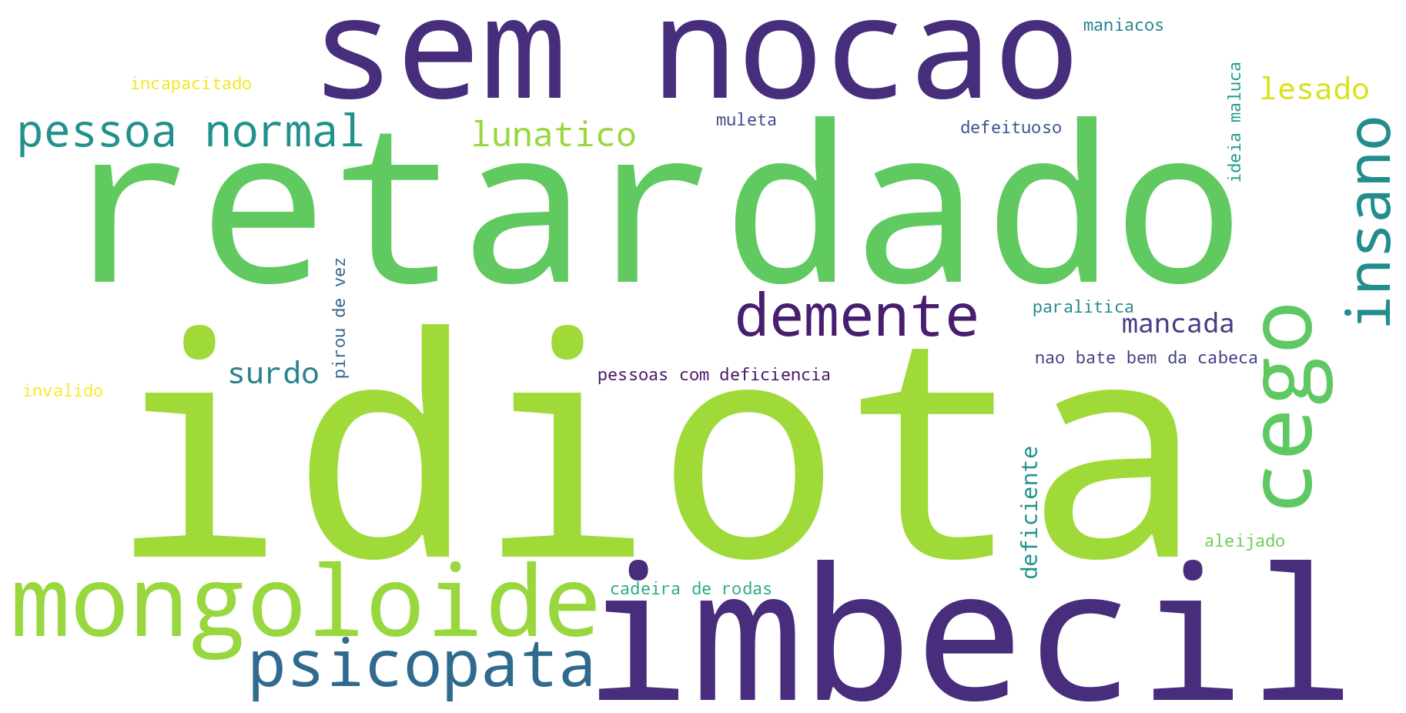

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=1800,
    height=900,
    background_color="white",
    collocations=False
).generate_from_frequencies(dict(contagem_termos_norm))

plt.figure(figsize=(18, 9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()



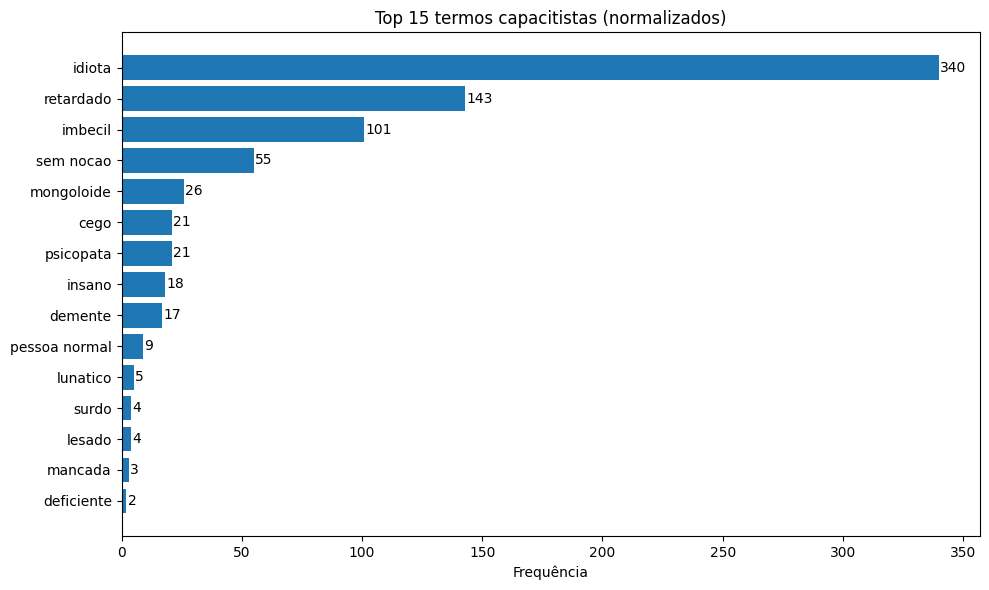

In [12]:
import matplotlib.pyplot as plt

top15 = contagem_termos_norm.most_common(15)
termos = [t for t, _ in top15]
freqs  = [q for _, q in top15]

plt.figure(figsize=(10, 6))
plt.barh(termos, freqs)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.title("Top 15 termos capacitistas (normalizados)")

for i, v in enumerate(freqs):
    plt.text(v + 0.5, i, str(v), va="center")

plt.tight_layout()
plt.show()


Análises no tupye_padronizado_capta_estagio1.csv

Ocorrências detectadas automaticamente: 781
Frases rotuladas manualmente: 99


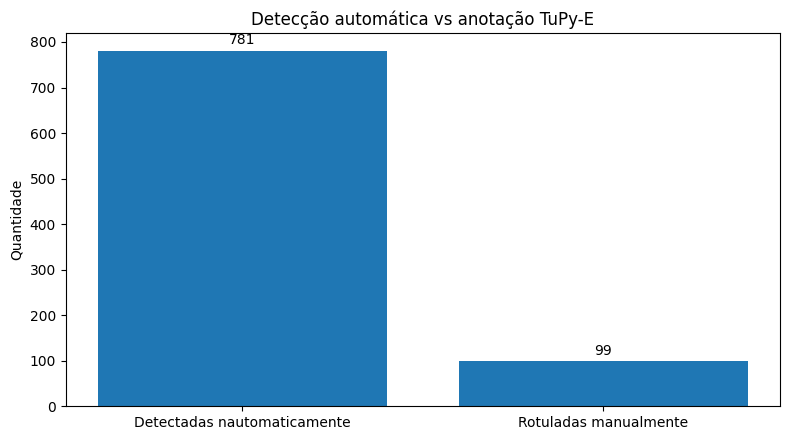

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Ler o arquivo
# =========================
path = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado_capta_estagio1.csv"



df = pd.read_csv(path)

# =========================
# 2) Cálculo das ocorrências
# =========================

# Total REAL de ocorrências detectadas automaticamente
detectadas = df["capacitism_capta_count"].fillna(0).astype(int).sum()

# Total de frases rotuladas manualmente como capacitismo
rotuladas = (df["capacitism"] == 1).sum()

print(f"Ocorrências detectadas automaticamente: {detectadas}")
print(f"Frases rotuladas manualmente: {rotuladas}")

# =========================
# 3) Gráfico de barras
# =========================
labels = [
    "Detectadas nautomaticamente",
    "Rotuladas manualmente"
]
values = [detectadas, rotuladas]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, values, color="tab:blue")

plt.title("Detecção automática vs anotação TuPy-E")
plt.ylabel("Quantidade")

# valores acima das barras
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(values) * 0.01,
        f"{int(h)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


Total de frases detectadas: 741
other                    300
political                 39
misogyny                  29
lgbtphobia                10
xenophobia                 9
racism                     9
body_shame                 5
aporophobia                3
religious_intolerance      2
ageism                     1
dtype: int64


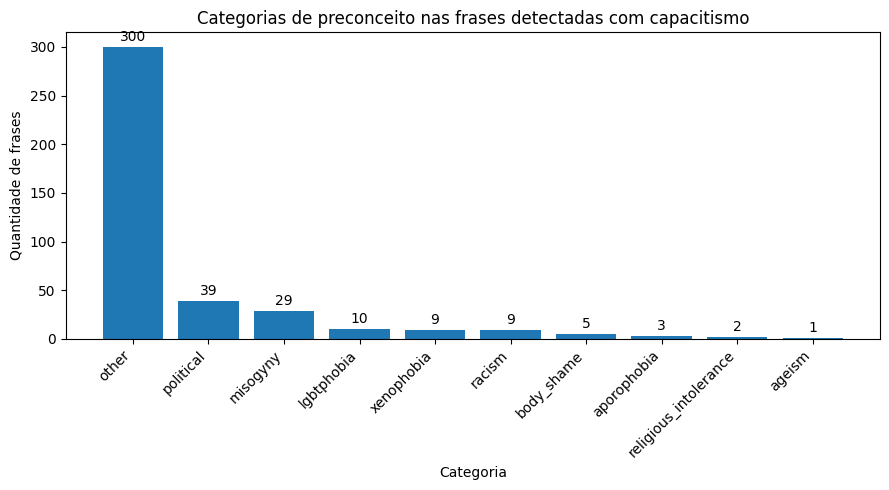

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Ler o arquivo
# =========================
path = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado_capta_estagio1.csv"


df = pd.read_csv(path)

# =========================
# 2) Filtrar frases detectadas com capacitismo
# =========================
df_cap = df[df["capacitism_capta_bin"] == 1]

print(f"Total de frases detectadas: {len(df_cap)}")

# =========================
# 3) Colunas de categorias
# =========================
categorias = [
    "political",
    "misogyny",
    "lgbtphobia",
    "racism",
    "xenophobia",
    "religious_intolerance",
    "aporophobia",
    "ageism",
    "body_shame",
    "other",
]

# manter apenas colunas existentes
categorias = [c for c in categorias if c in df_cap.columns]

# =========================
# 4) Contagem de coocorrências
# =========================
contagem = df_cap[categorias].fillna(0).astype(int).sum()
contagem = contagem.sort_values(ascending=False)

print(contagem)

# =========================
# 5) Gráfico de barras
# =========================
plt.figure(figsize=(9, 5))
plt.bar(contagem.index, contagem.values, color="tab:blue")

plt.title("Categorias de preconceito nas frases detectadas com capacitismo")
plt.ylabel("Quantidade de frases")
plt.xlabel("Categoria")

plt.xticks(rotation=45, ha="right")

# valores acima das barras
for i, v in enumerate(contagem.values):
    plt.text(i, v + max(contagem.values) * 0.01, str(int(v)),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()


Total de frases detectadas com capacitismo (CAPTA): 741


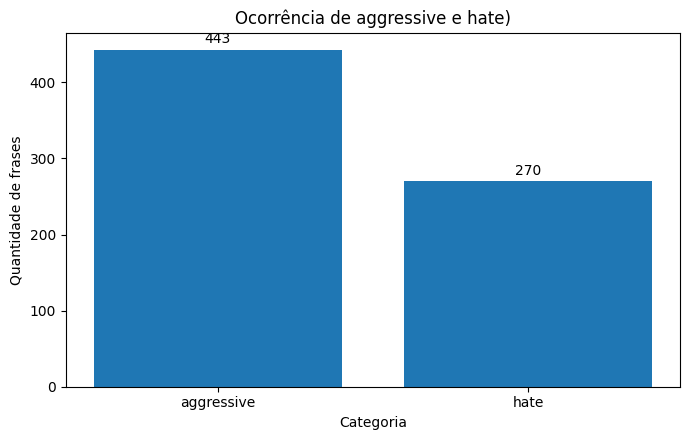

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Ler o arquivo
# =========================
path = "/content/drive/MyDrive/Mestrado/tuPyE/tupye_padronizado_capta_estagio1.csv"



df = pd.read_csv(path)

# =========================
# 2) Filtrar apenas frases detectadas com capacitismo (CAPTA)
# =========================
df_cap = df[df["capacitism_capta_bin"] == 1]
print("Total de frases detectadas com capacitismo (CAPTA):", len(df_cap))

# =========================
# 3) Contar ocorrências de aggressive e hate (binário 0/1)
# =========================
colunas = ["aggressive", "hate"]

# garantir que existem no dataframe
faltando = [c for c in colunas if c not in df_cap.columns]
if faltando:
    raise ValueError(f"Colunas ausentes no CSV: {faltando}. Colunas disponíveis: {list(df_cap.columns)}")

contagem = df_cap[colunas].fillna(0).astype(int).sum()

# =========================
# 4) Gráfico
# =========================
plt.figure(figsize=(7, 4.5))
bars = plt.bar(contagem.index, contagem.values, color="tab:blue")

plt.title("Ocorrência de aggressive e hate)")
plt.ylabel("Quantidade de frases")
plt.xlabel("Categoria")

# valores em cima das barras
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + max(contagem.values)*0.01,
        f"{int(h)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()
